# Compare Explanation Families

Simple Stage 2 comparison across explanation families and LLM judges.

Sections:

1. With Qwen, inspect method rankings inside each family and keep the methods hard-coded in `scripts/extract_best_prompts.py`.
2. Plot family score distributions by dataset and prompt type for each LLM judge.
3. Plot prompt-type differences against the aggregated no-explanation baseline for each LLM judge.

## 0. Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.extract_best_prompts import (
    BEST_ATTRIBUTION_METHOD,
    BEST_CONCEPT_INTERPRETATION,
    BEST_CONCEPT_METHOD,
    BEST_RATIONALE_METHODS,
)
from utils.analysis import filter_keep, preprocess, print_df_keys, score_diff
from utils.plot import (
    plot_accuracies_violins,
    plot_difference_bars,
    plot_pairwise_comparison_matrices,
)

DATA_DIR = REPO_ROOT / "data"
EXPORT_DIR = REPO_ROOT / "LaTeX-Simulatability-Shortcut" / "plots"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

JUDGE_FILES = {
    "qwen3.5-9b": "consim_Qwen_Qwen3.5-9B_v3.csv",
    "phi4": "consim_microsoft_phi-4_v3.csv",
    "gemma-4-12b": "consim_google_gemma-4-12B-it_v3.csv",
    "llama3.1-8b": "consim_meta-llama_Llama-3.1-8B-Instruct_v3.csv",
}
QWEN_JUDGE = "qwen3.5-9b"

def load_scores(path):
    raw = pd.read_csv(path)
    return preprocess(raw, seeds_per_bucket=5)

dfs = {}
for judge, file_name in JUDGE_FILES.items():
    path = DATA_DIR / file_name
    assert path.exists(), f"No score CSV found at {path}"
    dfs[judge] = load_scores(path)
    print(f"{judge}: {len(dfs[judge]):,} rows")

df_all = pd.concat([df for df in dfs.values() if not df.empty])
df_all = df_all.groupby(level=df_all.index.names, dropna=False).mean()
print_df_keys(dfs[QWEN_JUDGE])

qwen3.5-9b: 27,146 rows
phi4: 3,000 rows
gemma-4-12b: 2,200 rows
llama3.1-8b: 2,200 rows
DataFrame has 27,146 rows.
dataset: ['AG', 'BIOS', 'E', 'GE', 'IMDB', 'RT']
model: ['DB', 'RB', 'B']
classes_subset: ['[0, 1, 2, 3]', '[1, 21, 24]', '[21, 22, 26]', '[6, 19, 25]', '[9, 11, 18]', '[0, 1, 2, 3, 4, 5]', '[0, 4, 5]', '[2, 3, 27]', '[0, 1]']
group_seed: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
method: ['BatchTopKSAE', 'ClassesAs', 'ICA', 'KMeans', 'NeuronsAs', 'PCA', 'Qwen/Qwen3.5-2B', 'SVD', 'SemiNMF', 'VanillaSAE', 'baseline', 'gradient_shap', 'integrated_gradients', 'kernel_shap', 'lime', 'meta-llama/Llama-3.2-3B-Instruct', 'occlusion', 'saliency', 'smooth_grad', 'sobol', 'square_grad', 'var_grad']
interpretation: ['topk', nan, 'llm']
prompt_type: ['AC1', 'AC2', 'AC3', 'C1', 'C2', 'C3', 'AR1', 'R1', 'AB1', 'AB2', 'B1', 'B2', 'A1', 'AA1']
specification: ['new_consim', 'old_consim', 'simulator_consim', 'rationales', 'attributions']


## 0.1. Helpers

In [2]:
def family_method_rows(df):
    concepts = filter_keep(
        df,
        keep={"specification": ["new_consim"], "interpretation": ["topk"], "prompt_type": ["C1", "C2", "C3"]},
        filters={"method": ["baseline", "ClassesAs", "KMeans", "BatchTopKSAE"]},
    )
    rationales = filter_keep(
        df,
        keep={"specification": ["rationales"], "prompt_type": ["R1"]},
        filters={"method": ["baseline"]},
    )
    attributions = filter_keep(
        df,
        keep={"specification": ["attributions"], "prompt_type": ["A1"]},
        filters={"method": ["baseline"]},
    )
    return concepts, rationales, attributions

def selected_family_rows(df):
    concept_rows = filter_keep(
        df,
        keep={
            "specification": ["new_consim"],
            "method": [BEST_CONCEPT_METHOD],
            "interpretation": [BEST_CONCEPT_INTERPRETATION],
            "prompt_type": ["C1", "C2", "C3"],
        },
    )
    rationale_rows = filter_keep(
        df,
        keep={"specification": ["rationales"], "method": list(BEST_RATIONALE_METHODS), "prompt_type": ["R1"]},
    )
    attribution_rows = filter_keep(
        df,
        keep={"specification": ["attributions"], "method": [BEST_ATTRIBUTION_METHOD], "prompt_type": ["A1"]},
    )
    return concept_rows, rationale_rows, attribution_rows

def paired_cols(table):
    return [col for col in ["judge", "dataset", "model", "classes_subset", "group_seed"] if col in table.columns]

def aggregate_baseline(df, prompt_type):
    rows = filter_keep(
        df,
        keep={
            "specification": ["new_consim", "rationales", "attributions"],
            "method": ["baseline"],
            "prompt_type": [prompt_type],
        },
    )
    table = rows.reset_index(name="score")
    pair_cols = paired_cols(table)
    by_family = table.groupby(pair_cols + ["specification"])["score"].mean().reset_index()
    return by_family.groupby(pair_cols)["score"].mean()

def relabel_prompt(scores, label=None):
    table = scores.reset_index(name="score")
    if label is not None:
        table["prompt_type"] = label
    return table.set_index(paired_cols(table) + ["prompt_type"])["score"]

def scores_for_judge(df):
    concept_rows, rationale_rows, attribution_rows = selected_family_rows(df)
    baseline_b1 = aggregate_baseline(df, "B1")
    baseline_b2 = aggregate_baseline(df, "B2")

    scores = pd.concat([
        relabel_prompt(concept_rows),
        relabel_prompt(rationale_rows, "R"),
        relabel_prompt(attribution_rows, "A"),
        relabel_prompt(baseline_b1, "B1"),
        relabel_prompt(baseline_b2, "B2"),
    ])

    return scores, {"B1": baseline_b1, "B2": baseline_b2}

def differences_to_baseline(scores, baselines):
    differences = []
    for prompt_type in ["C1", "C2", "C3", "R", "A"]:
        prompt_scores = scores.xs(prompt_type, level="prompt_type")
        baseline_rows = baselines["B1" if prompt_type == "C1" else "B2"]
        diff = score_diff(baseline_rows, prompt_scores)
        table = diff.reset_index(name="score")
        table["prompt_type"] = prompt_type
        differences.append(table.set_index(paired_cols(table) + ["prompt_type"])["score"])

    return pd.concat(differences)

## 1. Qwen Method Checks

The hard-coded best prompt methods are `VanillaSAE` concepts with `topk`, `Qwen/Qwen3.5-2B` rationales, and `lime` attributions. The pairwise matrices below are only for checking that these choices look coherent under the Qwen judge.

## concepts


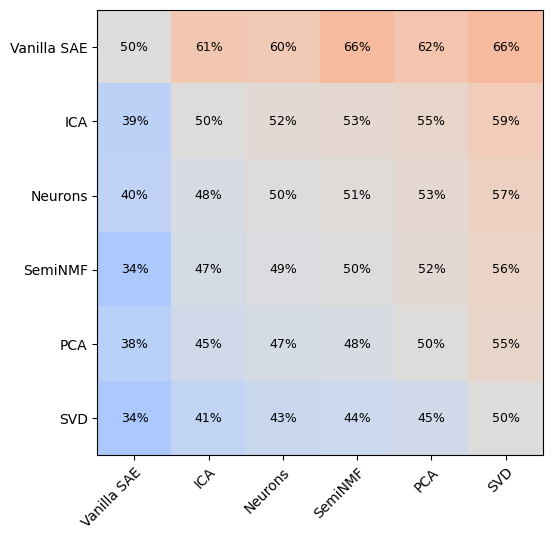

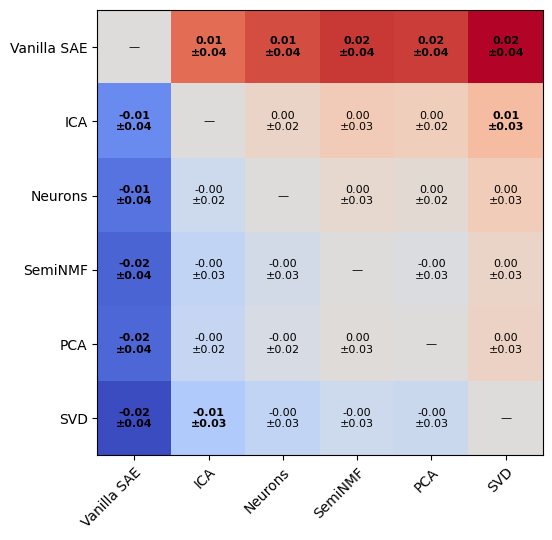

## rationales


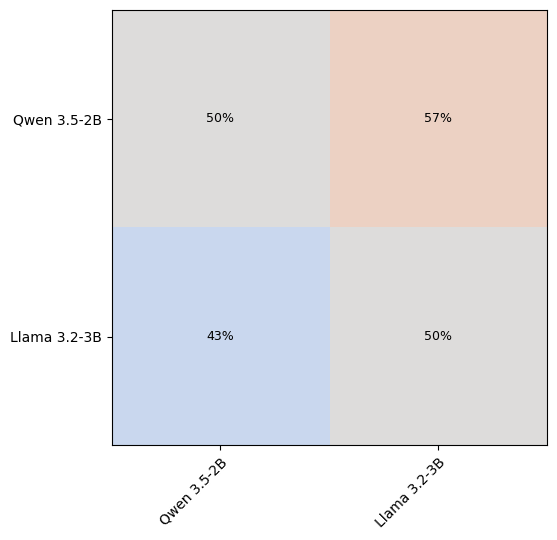

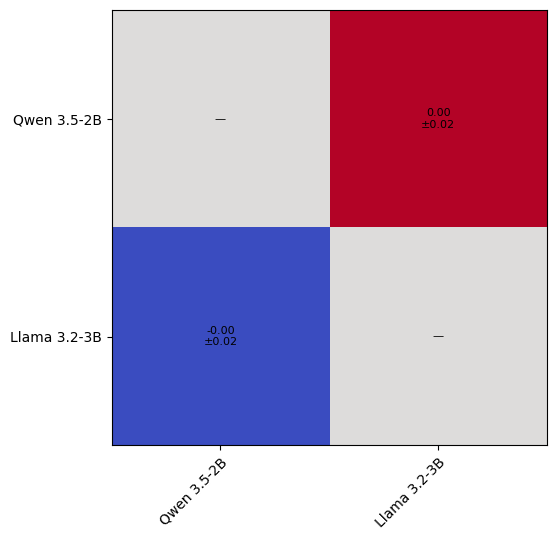

## attributions


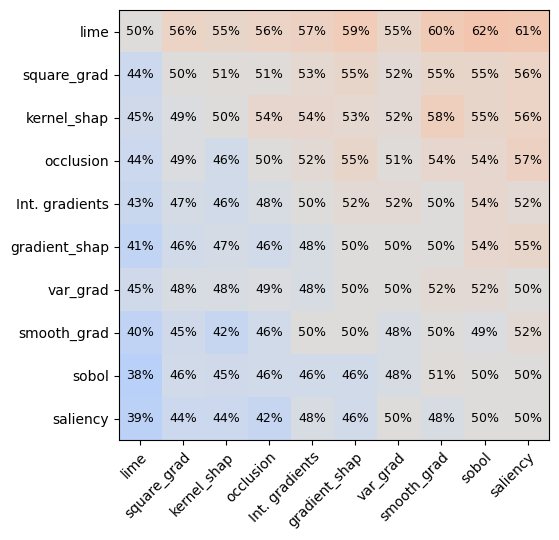

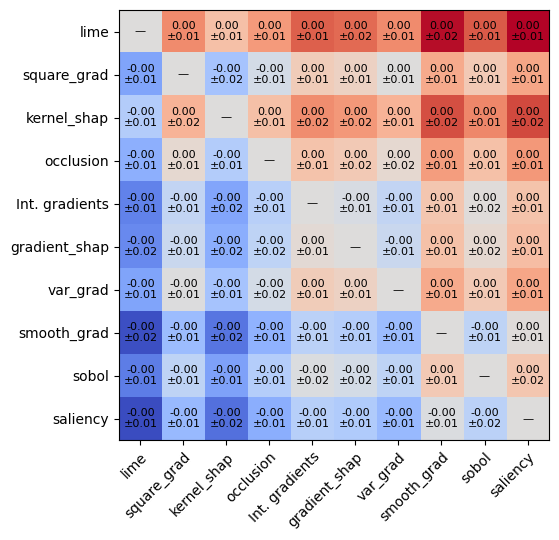

In [3]:
qwen_concepts, qwen_rationales, qwen_attributions = family_method_rows(dfs[QWEN_JUDGE])

for name, scores in [
    ("concepts", qwen_concepts),
    ("rationales", qwen_rationales),
    ("attributions", qwen_attributions),
]:
    print(f"## {name}")
    fig_pct, fig_diff, percentage_matrix, difference_matrix = plot_pairwise_comparison_matrices(
        scores,
        compared_index="method",
        figsize=(7, 5.5),
    )
    fig_pct.savefig(EXPORT_DIR / f"families_qwen_{name}_method_winrate.pdf", bbox_inches="tight")
    fig_diff.savefig(EXPORT_DIR / f"families_qwen_{name}_method_difference.pdf", bbox_inches="tight")
    plt.show()

## 2. Violin Plots by LLM Judge

Each plot keeps only the hard-coded best methods and includes `B1` and `B2` separately. Duplicate baseline rows are still averaged across specifications within each baseline type.

## qwen3.5-9b


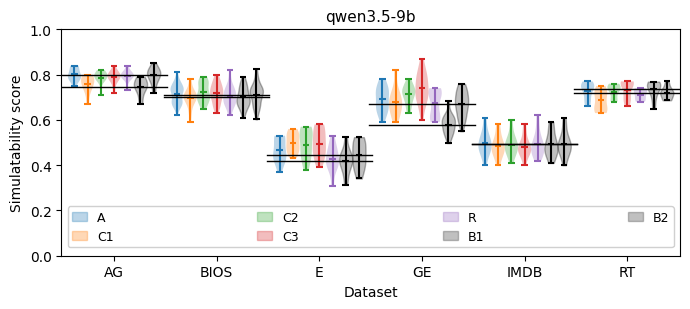

## phi4


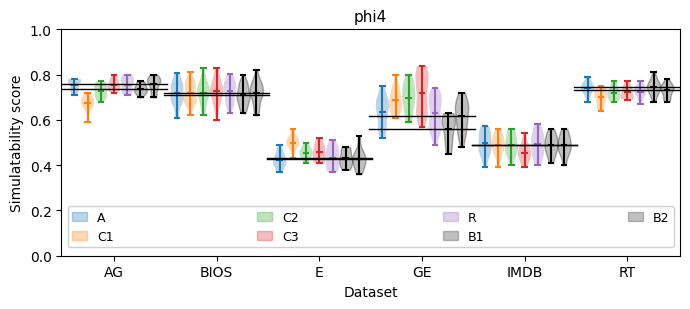

## gemma-4-12b


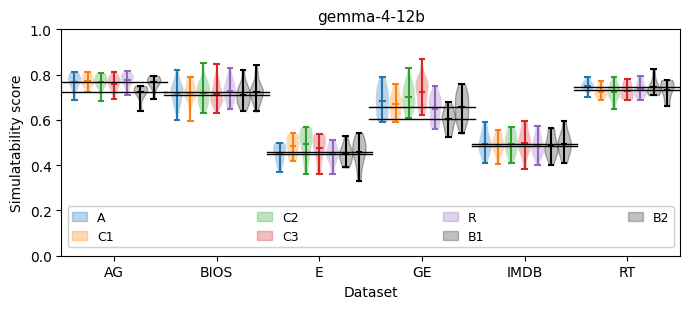

## llama3.1-8b


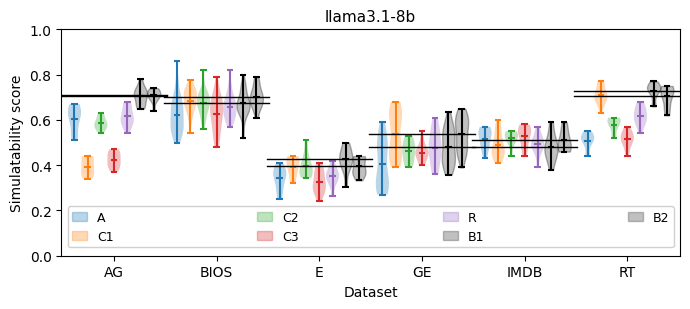

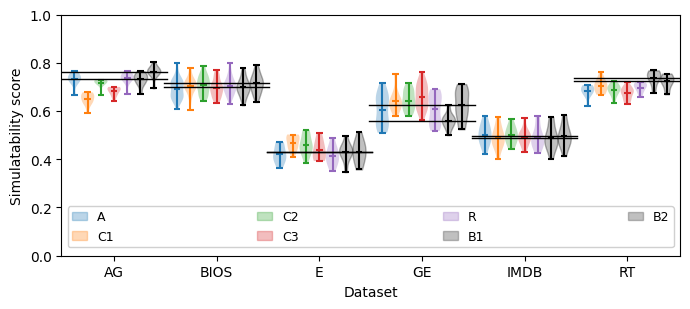

In [4]:
plot_outputs = {}
for judge, df in dfs.items():
    print(f"## {judge}")
    if df.empty:
        print("No numeric score rows; skipping plots.")
        continue
    scores, baseline_rows = scores_for_judge(df)
    fig, _ = plot_accuracies_violins(scores, group_col="dataset", atom_col="prompt_type", title=judge, figsize=(7, 3.2))
    fig.savefig(EXPORT_DIR / f"families_violins_{judge}.pdf", bbox_inches="tight")
    plt.show()
    plot_outputs[judge] = {"scores": scores, "baseline": baseline_rows}

scores, baseline_rows = scores_for_judge(df_all)
fig, _ = plot_accuracies_violins(scores, group_col="dataset", atom_col="prompt_type", figsize=(7, 3.2))
fig.savefig(EXPORT_DIR / "families_violins_all_judges.pdf", bbox_inches="tight")
plt.show()
plot_outputs["all_judges"] = {"scores": scores, "baseline": baseline_rows}

## 3. Bar Plots by LLM Judge

Each bar compares one prompt type to its matching baseline: `C1` against `B1`, and `C2`, `C3`, `R`, `A` against `B2`.

## qwen3.5-9b


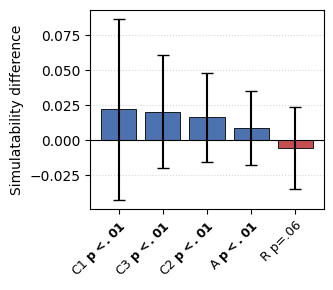

## phi4


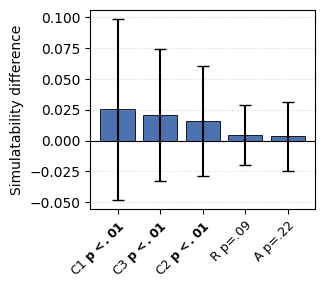

## gemma-4-12b


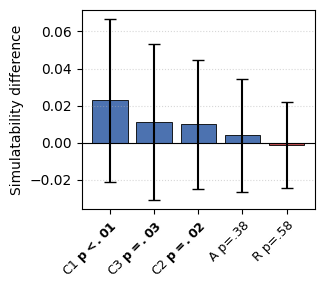

## llama3.1-8b


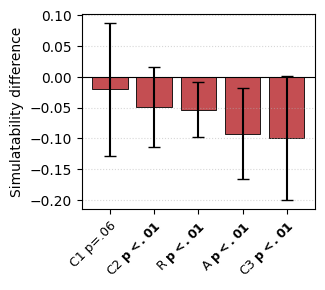

## all_judges


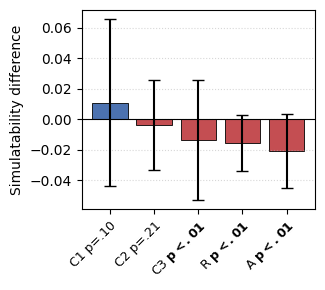

In [5]:
for judge, output in plot_outputs.items():
    print(f"## {judge}")
    differences = differences_to_baseline(output["scores"], output["baseline"])
    fig, _ = plot_difference_bars(
        differences,
        comparison_col="prompt_type",
        ylabel="Simulatability difference",
    )
    fig.savefig(EXPORT_DIR / f"families_prompt_type_diff_{judge}.pdf", bbox_inches="tight")
    plt.show()
    plot_outputs[judge]["differences"] = differences

## 4. Pairwise Prompt-Type Matrices by LLM Judge

Compare the selected prompt types directly: `A`, `B1`, `B2`, `R`, `C1`, `C2`, `C3`.

## qwen3.5-9b


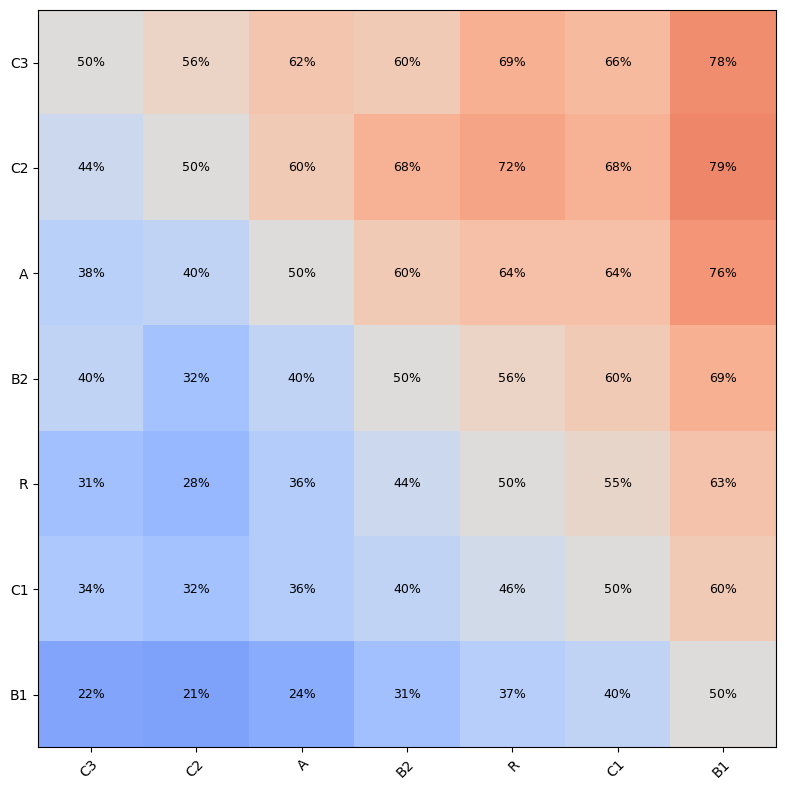

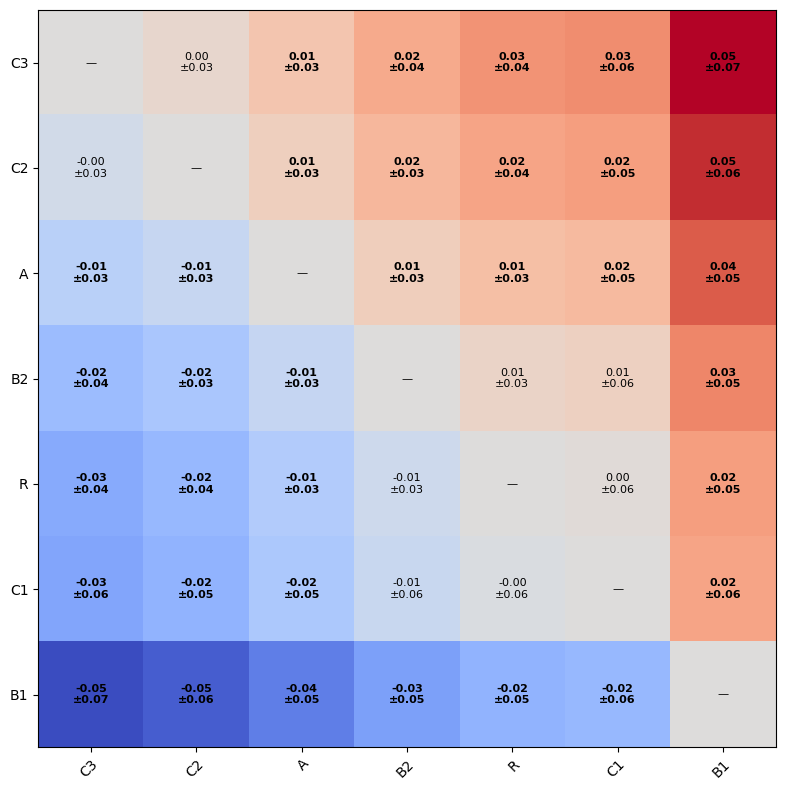

## phi4


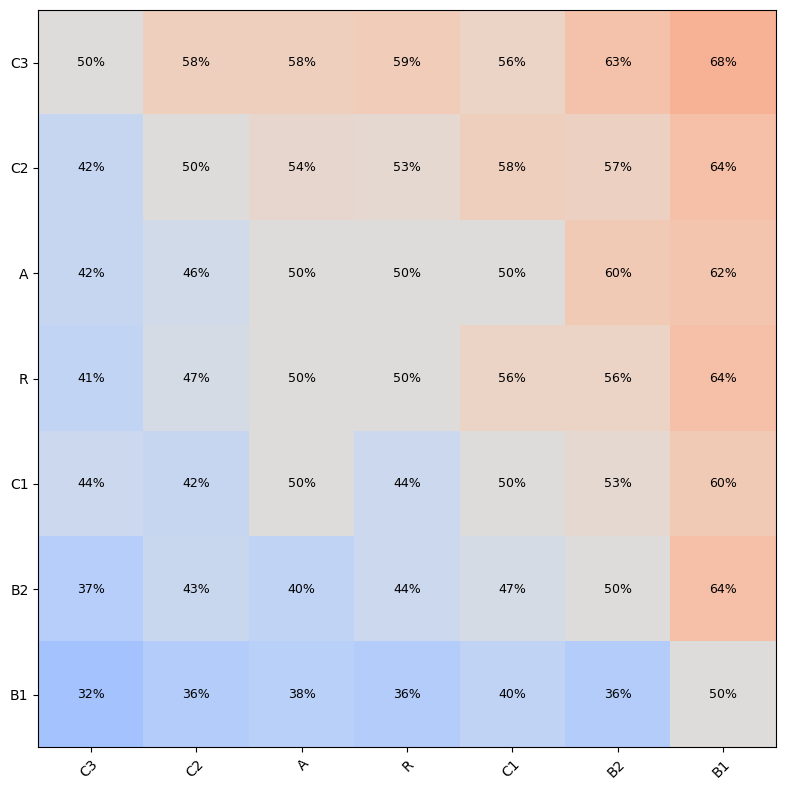

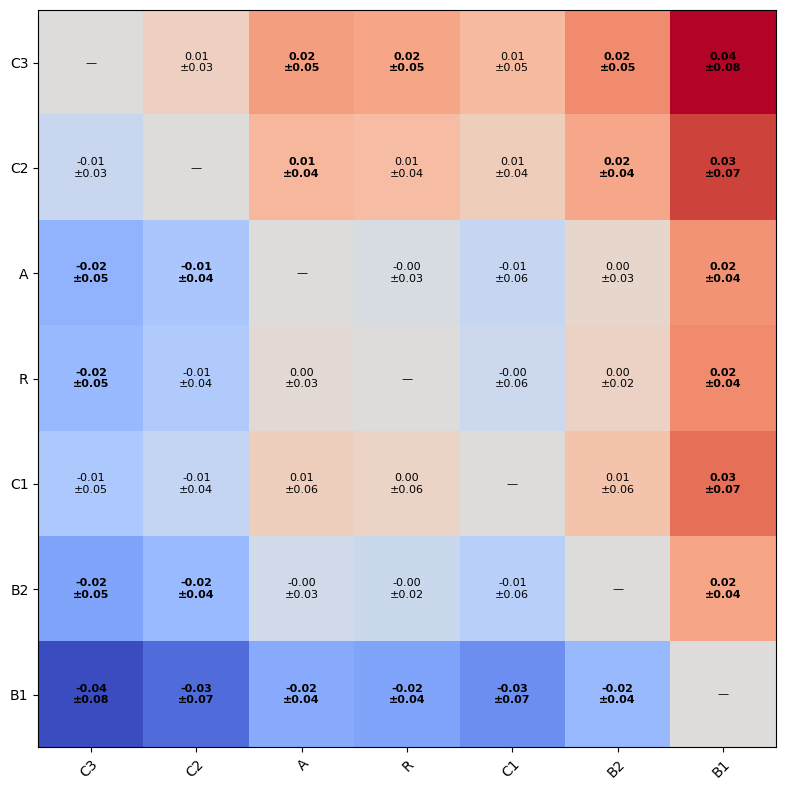

## gemma-4-12b


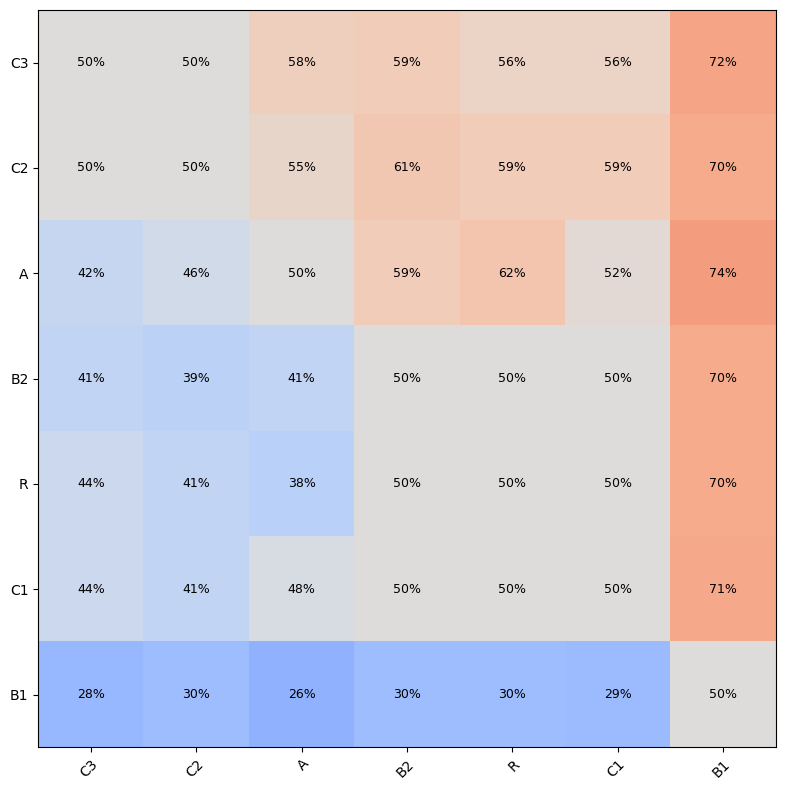

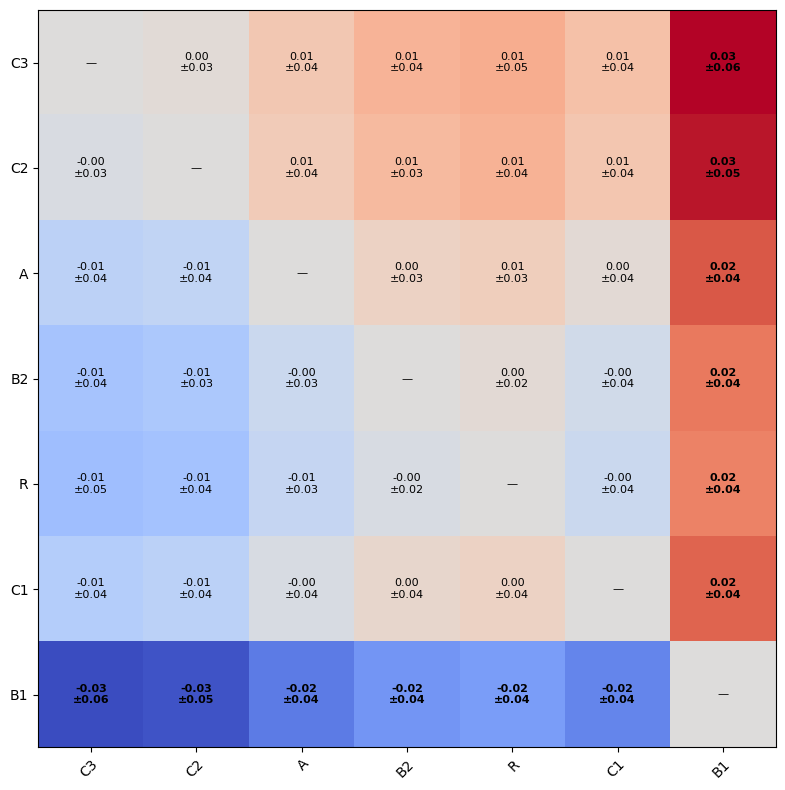

## llama3.1-8b


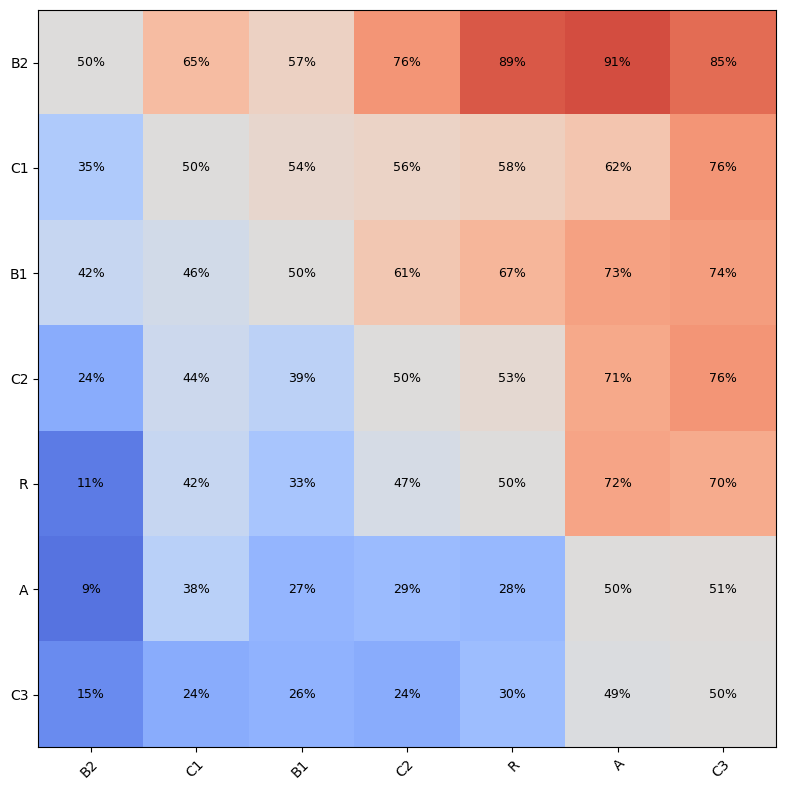

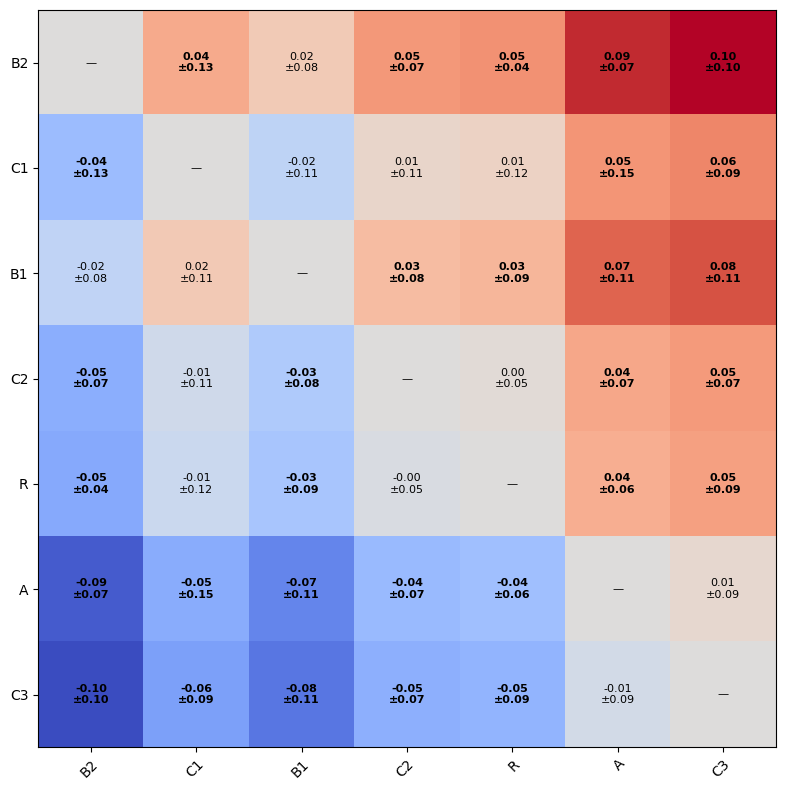

## all_judges


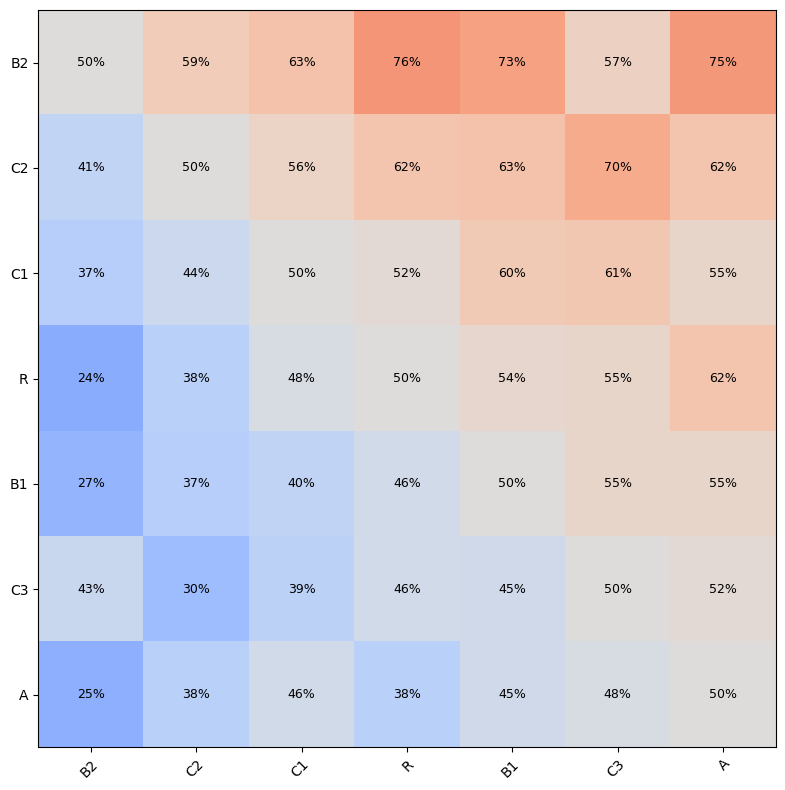

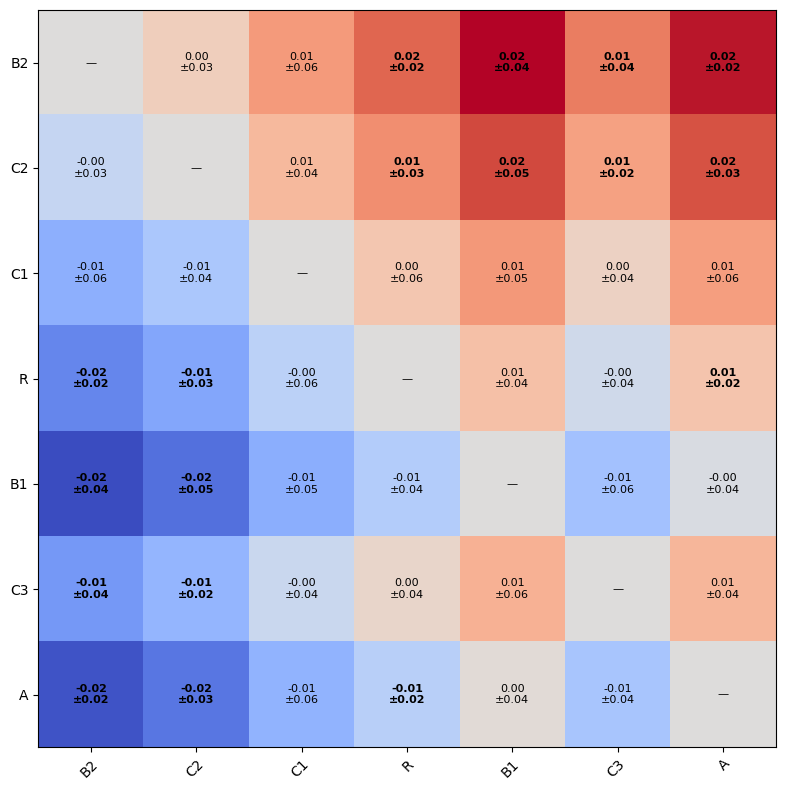

In [6]:
for judge, output in plot_outputs.items():
    print(f"## {judge}")
    fig_pct, fig_diff, percentage_matrix, difference_matrix = plot_pairwise_comparison_matrices(
        output["scores"],
        compared_index="prompt_type",
        figsize=(10, 8),
    )
    fig_pct.savefig(EXPORT_DIR / f"families_prompt_type_pairwise_winrate_{judge}.pdf", bbox_inches="tight")
    fig_diff.savefig(EXPORT_DIR / f"families_prompt_type_pairwise_difference_{judge}.pdf", bbox_inches="tight")
    plt.show()